In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from matplotlib.ticker import LogLocator, NullFormatter




# ======= PLOT SETTINGS =======
plt.rcParams.update({
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})
N = n_states = 100
L = 300

mat_data_y = np.loadtxt("paired_splitting_data_joined_N100_y.dat")
mat_data_z = np.loadtxt("paired_splitting_data_joined_N100_z.dat")
overlap_data = np.loadtxt(f"overlap_data_N{N}.dat")
bulk_energy = np.loadtxt("bulk_energy_o.dat")

In [12]:
def highlight_largest_points(
    ax,
    data,
    n=3,
    circle_size=90,
    edgecolor="red",
    linewidth=1.6
):
    """
    Draw open circles around the n points with the largest y-values
    and return their indices sorted from left to right.
    """
    x = data[:, 0]
    y = data[:, 1]

    valid = np.isfinite(x) & np.isfinite(y)
    valid_indices = np.flatnonzero(valid)

    if len(valid_indices) < n:
        raise ValueError(
            f"Only {len(valid_indices)} valid points are available; "
            f"cannot highlight {n} points."
        )

    # Indices of the n largest y-values
    largest_indices = valid_indices[np.argsort(y[valid])[-n:]]

    # Sort those selected points from left to right in energy
    largest_indices = largest_indices[np.argsort(x[largest_indices])]

    ax.scatter(
        x[largest_indices],
        y[largest_indices],
        s=circle_size,
        facecolors="none",
        edgecolors=edgecolor,
        linewidths=linewidth,
        marker="o",
        zorder=10
    )

    return largest_indices




def annotate_selected_points(ax, data, indices, labels, offsets):
    """
    Add text labels to selected points.

    Parameters
    ----------
    ax : matplotlib axis
    data : ndarray
        Two-column array [x, y]
    indices : array-like
        Indices of points to annotate
    labels : list of str
        Labels to place
    offsets : list of tuple
        Offsets in points, e.g. [(8,10), (8,10), (8,-5)]
    """
    x = data[:, 0]
    y = data[:, 1]

    for idx, label, offset in zip(indices, labels, offsets):
        ax.annotate(
            label,
            xy=(x[idx], y[idx]),
            xytext=offset,
            textcoords="offset points",
            fontsize=13,
            ha="left",
            va="center"
        )

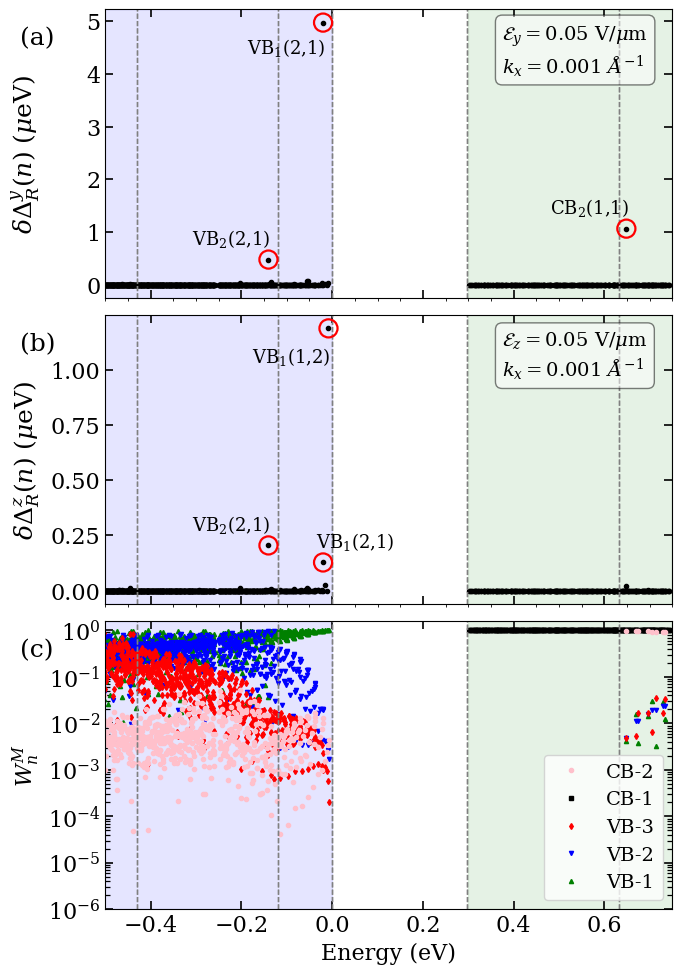

In [13]:
# ==================================================
# Combined 3 x 1 figure with a shared energy axis
# ==================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(7, 10),
    sharex=True,
    gridspec_kw={"hspace": 0.06}
)

ax_a, ax_b, ax_c = axes

# Common energy range
energy_min, energy_max = -0.6, 0.75


def add_common_background(ax):
    """Add the shaded energy windows and bulk-energy guide lines."""
    ax.axvspan(energy_min, 0.0, color="blue", alpha=0.1)
    ax.axvspan(0.3, energy_max, color="green", alpha=0.1)

    for energy in bulk_energy:
        ax.axvline(
            x=energy,
            linestyle="--",
            color="gray",
            linewidth=1.0
        )

    ax.set_xlim(-0.5, energy_max)


def style_axis(ax, minor_y=False):
    """Apply consistent inward-facing ticks to each panel."""
    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        top=True,
        right=True,
        length=6,
        width=1.2,
        labelsize=14
    )

    if minor_y:
        ax.minorticks_on()
        ax.tick_params(
            axis="y",
            which="minor",
            direction="in",
            left=True,
            right=True,
            length=3,
            width=1.0
        )
        ax.tick_params(
            axis="x",
            which="minor",
            bottom=False,
            top=False
        )


def add_panel_label(ax, label):
    """Place the panel label at the upper-left corner."""
    ax.text(
        -0.15,
        0.94,
        label,
        transform=ax.transAxes,
        fontsize=18,
        # fontweight="bold",
        va="top",
        ha="left"
    )


# --------------------------------------------------
# (a) y matrix-element contribution
# --------------------------------------------------
ax_a.plot(
    mat_data_y[:, 0],
    mat_data_y[:, 1],
    "o",
    color="black",
    markersize=3,
    label="Rashba Splitting"
)

# Highlight top 3 points and get their indices (left to right)
idx_a = highlight_largest_points(
    ax_a,
    mat_data_y,
    n=3,
    circle_size=170
)

labels_a = [
    r"VB$_2$(2,1)",
    r"VB$_1$(2,1)",
    r"CB$_2$(1,1)"
]

# Adjust these if you want slightly different placement
offsets_a = [
    (-55, 15),   # label for left point
    (-55, -18),  # label for middle/top point
    (-55, 15)      # label for right point
]

annotate_selected_points(ax_a, mat_data_y, idx_a, labels_a, offsets_a)


add_common_background(ax_a)
ax_a.set_ylabel(r"$\delta\Delta_R^{y}(n)$ ($\mu$eV)", fontsize=18)

textstr_a = (
    r"$\mathcal{E}_y = 0.05$ V/$\mu$m" + "\n" +
    r"$k_x = 0.001$ $\AA^{-1}$"
)

ax_a.text(
    0.7,
    0.95,
    textstr_a,
    transform=ax_a.transAxes,
    fontsize=14,
    va="top",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="black",
        alpha=0.5
    )
)

add_panel_label(ax_a, "(a)")
style_axis(ax_a)


# --------------------------------------------------
# (b) z matrix-element contribution
# --------------------------------------------------
ax_b.plot(
    mat_data_z[:, 0],
    mat_data_z[:, 1],
    "o",
    color="black",
    markersize=3,
    label="Rashba Splitting"
)

# Highlight top 3 points and get their indices (left to right)
idx_b = highlight_largest_points(
    ax_b,
    mat_data_z,
    n=3,
    circle_size=170
)

labels_b = [
    r"VB$_2$(2,1)",
    r"VB$_1$(2,1)",
    r"VB$_1$(1,2)"
]

offsets_b = [
    (-55, 15),   # left point
    (-5, 15),    # middle point
    (-55, -20)     # right/top point
]

annotate_selected_points(ax_b, mat_data_z, idx_b, labels_b, offsets_b)

add_common_background(ax_b)
ax_b.set_ylabel(r"$\delta\Delta_R^{z}(n)$ ($\mu$eV)", fontsize=18)
textstr_b = (
    r"$\mathcal{E}_z = 0.05$ V/$\mu$m" + "\n" +
    r"$k_x = 0.001$ $\AA^{-1}$"
)
ax_b.text(
    0.7,
    0.95,
    textstr_b,
    transform=ax_b.transAxes,
    fontsize=14,
    va="top",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="black",
        alpha=0.5
    )
)

add_panel_label(ax_b, "(b)")
style_axis(ax_b)


# --------------------------------------------------
# (c) overlap data
# --------------------------------------------------
color_list = ["r", "b", "g", "k", "pink"]
legend_list = ["VB-1", "VB-2", "VB-3", "CB-1", "CB-2"]
symbol_list = ["d", "v", "^", "s", "o"]

for i in range(2, -1, -1):
    ax_c.plot(
        overlap_data[:, 0],
        overlap_data[:, i + 1],
        symbol_list[i],
        label=legend_list[abs(i - 2)],
        color=color_list[i],
        markersize=3
    )

for i in range(3, 5):
    ax_c.plot(
        overlap_data[:, 0],
        overlap_data[:, i + 1],
        symbol_list[i],
        label=legend_list[i],
        color=color_list[i],
        markersize=3
    )

add_common_background(ax_c)
ax_c.set_yscale("log")
ax_c.set_ylim(10**-6, 10**0.2)
ax_c.set_ylabel(r"$W_n^M$", fontsize=16)
ax_c.set_xlabel("Energy (eV)", fontsize=16)

handles, labels = ax_c.get_legend_handles_labels()
ax_c.legend(
    handles[::-1],
    labels[::-1],
    frameon=True,
    loc="lower right",
    fontsize=14,
    ncol=1
)

add_panel_label(ax_c, "(c)")
style_axis(ax_c, minor_y=True)


# --------------------------------------------------
# Force minor ticks on the compact logarithmic axis
# --------------------------------------------------
ax_c.yaxis.set_major_locator(
    LogLocator(
        base=10.0,
        numticks=20
    )
)

ax_c.yaxis.set_minor_locator(
    LogLocator(
        base=10.0,
        subs=np.arange(2, 10) * 0.1,
        numticks=100
    )
)

ax_c.yaxis.set_minor_formatter(NullFormatter())

ax_c.tick_params(
    axis="y",
    which="minor",
    direction="in",
    left=True,
    right=True,
    length=3.5,
    width=0.9
)









# Only the bottom panel displays the shared x-axis tick labels.
ax_a.tick_params(labelbottom=False, labelsize = 16)
ax_b.tick_params(labelbottom=False, labelsize = 16)
ax_c.tick_params(labelbottom=True, labelsize = 16)

fig.align_ylabels(axes)
fig.subplots_adjust(left=0.16, right=0.97, bottom=0.08, top=0.98, hspace=0.06)

# Optional publication-quality output:
fig.savefig("splitting_energy_plot.pdf", bbox_inches="tight")
fig.savefig("splitting_energy_plot.png", dpi=300, bbox_inches="tight")
fig.savefig("splitting_energy_plot.svg", bbox_inches="tight")

plt.show()


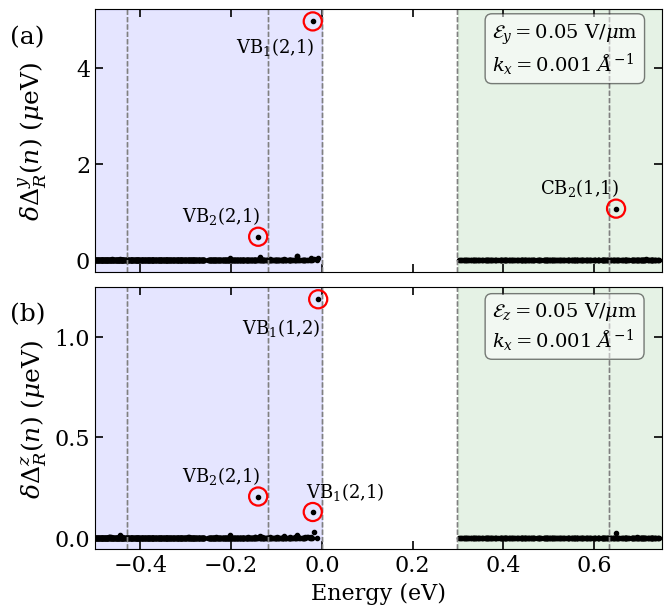

In [14]:
# ==================================================
# Combined 3 x 1 figure with a shared energy axis
# ==================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(7, 6),
    sharex=True,
    gridspec_kw={"hspace": 0.06}
)

ax_a, ax_b = axes

# Common energy range
energy_min, energy_max = -0.6, 0.75


def add_common_background(ax):
    """Add the shaded energy windows and bulk-energy guide lines."""
    ax.axvspan(energy_min, 0.0, color="blue", alpha=0.1)
    ax.axvspan(0.3, energy_max, color="green", alpha=0.1)

    for energy in bulk_energy:
        ax.axvline(
            x=energy,
            linestyle="--",
            color="gray",
            linewidth=1.0
        )

    ax.set_xlim(-0.5, energy_max)


def style_axis(ax, minor_y=False):
    """Apply consistent inward-facing ticks to each panel."""
    ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        top=True,
        right=True,
        length=6,
        width=1.2,
        labelsize=14
    )

    if minor_y:
        ax.minorticks_on()
        ax.tick_params(
            axis="y",
            which="minor",
            direction="in",
            left=True,
            right=True,
            length=3,
            width=1.0
        )
        ax.tick_params(
            axis="x",
            which="minor",
            bottom=False,
            top=False
        )


def add_panel_label(ax, label):
    """Place the panel label at the upper-left corner."""
    ax.text(
        -0.15,
        0.94,
        label,
        transform=ax.transAxes,
        fontsize=18,
        # fontweight="bold",
        va="top",
        ha="left"
    )


# --------------------------------------------------
# (a) y matrix-element contribution
# --------------------------------------------------
ax_a.plot(
    mat_data_y[:, 0],
    mat_data_y[:, 1],
    "o",
    color="black",
    markersize=3,
    label="Rashba Splitting"
)

# Highlight top 3 points and get their indices (left to right)
idx_a = highlight_largest_points(
    ax_a,
    mat_data_y,
    n=3,
    circle_size=170
)

labels_a = [
    r"VB$_2$(2,1)",
    r"VB$_1$(2,1)",
    r"CB$_2$(1,1)"
]

# Adjust these if you want slightly different placement
offsets_a = [
    (-55, 15),   # label for left point
    (-55, -18),  # label for middle/top point
    (-55, 15)      # label for right point
]

annotate_selected_points(ax_a, mat_data_y, idx_a, labels_a, offsets_a)


add_common_background(ax_a)
ax_a.set_ylabel(r"$\delta\Delta_R^{y}(n)$ ($\mu$eV)", fontsize=18)

textstr_a = (
    r"$\mathcal{E}_y = 0.05$ V/$\mu$m" + "\n" +
    r"$k_x = 0.001$ $\AA^{-1}$"
)

ax_a.text(
    0.7,
    0.95,
    textstr_a,
    transform=ax_a.transAxes,
    fontsize=14,
    va="top",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="black",
        alpha=0.5
    )
)

add_panel_label(ax_a, "(a)")
style_axis(ax_a)


# --------------------------------------------------
# (b) z matrix-element contribution
# --------------------------------------------------
ax_b.plot(
    mat_data_z[:, 0],
    mat_data_z[:, 1],
    "o",
    color="black",
    markersize=3,
    label="Rashba Splitting"
)

# Highlight top 3 points and get their indices (left to right)
idx_b = highlight_largest_points(
    ax_b,
    mat_data_z,
    n=3,
    circle_size=170
)

labels_b = [
    r"VB$_2$(2,1)",
    r"VB$_1$(2,1)",
    r"VB$_1$(1,2)"
]

offsets_b = [
    (-55, 15),   # left point
    (-5, 15),    # middle point
    (-55, -20)     # right/top point
]

annotate_selected_points(ax_b, mat_data_z, idx_b, labels_b, offsets_b)

add_common_background(ax_b)
ax_b.set_ylabel(r"$\delta\Delta_R^{z}(n)$ ($\mu$eV)", fontsize=18)
textstr_b = (
    r"$\mathcal{E}_z = 0.05$ V/$\mu$m" + "\n" +
    r"$k_x = 0.001$ $\AA^{-1}$"
)
ax_b.text(
    0.7,
    0.95,
    textstr_b,
    transform=ax_b.transAxes,
    fontsize=14,
    va="top",
    ha="left",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="black",
        alpha=0.5
    )
)
ax_b.set_xlabel("Energy (eV)", fontsize=16)
add_panel_label(ax_b, "(b)")
style_axis(ax_b)


# Only the bottom panel displays the shared x-axis tick labels.
ax_a.tick_params(labelbottom=False, labelsize = 16)
ax_b.tick_params(labelbottom=True, labelsize = 16)

fig.align_ylabels(axes)
fig.subplots_adjust(left=0.16, right=0.97, bottom=0.08, top=0.98, hspace=0.06)

# Optional publication-quality output:
fig.savefig("splitting_energy_plot_2.pdf", bbox_inches="tight")
fig.savefig("splitting_energy_plot_2.png", dpi=300, bbox_inches="tight")
fig.savefig("splitting_energy_plot_2.svg", bbox_inches="tight")

plt.show()
